In [ ]:
import cv2
import numpy as np

# Charger l'image
img = cv2.imread("dataset\lascaux\Lascaux_001.jpg")
if img is None:
    raise IOError("Image non trouvée")

# OpenCV travaille en BGR
# img = cv2.resize(img, None, fx=0.5, fy=0.5)

# =========================
# Mean Shift segmentation
# =========================
# sp : bande passante spatiale (hs)
# sr : bande passante couleur (hr)
# maxLevel : niveaux de pyramide
segmented = cv2.pyrMeanShiftFiltering(
    img,
    sp=200,      # hs
    sr=200,      # hr
    maxLevel=1,
    termcrit=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 5, 1)
)

h, w, _ = segmented.shape
flat = segmented.reshape(-1, 3)

colors, labels = np.unique(flat, axis=0, return_inverse=True)
labels = labels.reshape(h, w)

def region_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)

    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1] or \
               labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 255

    return boundaries


boundaries = region_boundaries(labels)

# Copier l'image segmentée
result = segmented.copy()

# Frontières en noir (comme dans le papier)
result[boundaries == 255] = (255, 255, 255)

cv2.imshow("Mean Shift + Boundaries", result)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [1]:
import numpy as np
import cv2
from sklearn.cluster import MeanShift
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [426]:
# img = cv2.imread("Segmentation-of-Cave-Paintings/dataset/mains/Cueva_de_las_manos_-_detalle.jpg")  # image couleur ou niveaux de gris
img = cv2.imread("Segmentation-of-Cave-Paintings/dataset/lascaux/Lascaux_01.jpg")  # image couleur ou niveaux de gris
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
# img=img[700:,900:,:]
h, w = img.shape[:2]

In [427]:
def denoise(img, method=None, g_sigma=1.0, m_ksize=5):
    if method is None:
        return img
    if method == "gaussian":
        k = int(g_sigma*6+1)|1
        return cv2.GaussianBlur(img,(k,k),g_sigma)
    if method == "median":
        if m_ksize % 2 == 0:
            m_ksize += 1
        return cv2.medianBlur(img, m_ksize)
    raise ValueError(method)

denoised_img=denoise(img, method=None, g_sigma=2)

In [428]:
xs, ys = np.meshgrid(np.arange(w), np.arange(h))
# if img.ndim == 2:  # niveaux de gris
#     features = np.column_stack((xs.flatten(), ys.flatten(), denoised_img.flatten()))
# else:  # couleur
#     features = np.column_stack((xs.flatten(), ys.flatten(), denoised_img.reshape(-1, 3)))

# features = features.astype(np.float32)

features = np.column_stack((
    xs.flatten() / w,
    ys.flatten() / h,
    denoised_img.reshape(-1, 3)
)).astype(np.float32)

features[:, 2:] /= np.array([100, 128, 128])

In [429]:
hs = 0.5  # bande spatiale
hr = 0.06  # bande couleur
features[:, 0:2] /= hs
if img.ndim == 2:
    features[:, 2] /= hr
else:
    features[:, 2:5] /= hr

In [430]:
ms = MeanShift(bandwidth=1.0, bin_seeding=True)
print("Clustering Mean Shift ...")
labels = ms.fit_predict(features)
labels_img = labels.reshape(h, w)

Clustering Mean Shift ...


In [431]:
np.unique(labels_img)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53])

In [432]:
min_size = 0  # pixels

import numpy as np
from scipy.spatial import cKDTree

def merge_small_regions(labels_img, features, min_size):
    labels = labels_img.flatten().copy()

    while True:
        unique, counts = np.unique(labels, return_counts=True)

        # régions trop petites
        small_labels = unique[counts < min_size]
        if len(small_labels) == 0:
            break  # plus rien à merger

        # calcul des centres
        centers = []
        valid_labels = []

        for lab, cnt in zip(unique, counts):
            if cnt >= min_size:
                centers.append(features[labels == lab].mean(axis=0))
                valid_labels.append(lab)

        centers = np.array(centers)
        tree = cKDTree(centers)

        # merge des petites régions
        for lab in small_labels:
            center = features[labels == lab].mean(axis=0)
            _, idx = tree.query(center)
            labels[labels == lab] = valid_labels[idx]

    return labels.reshape(labels_img.shape)


new_labels_img = merge_small_regions(labels_img, features, min_size)

In [433]:
def region_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)
    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1] or labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 255
    return boundaries

boundaries = region_boundaries(new_labels_img)

In [434]:
segmented = np.zeros_like(img)
for lab in np.unique(labels_img):
    mask = labels_img == lab
    segmented.reshape(-1, img.shape[2])[mask.flatten()] = img.reshape(-1, img.shape[2])[mask.flatten()].mean(axis=0)

# Superposer les frontières en noir
result = segmented.copy()
# result[boundaries == 255] = 0

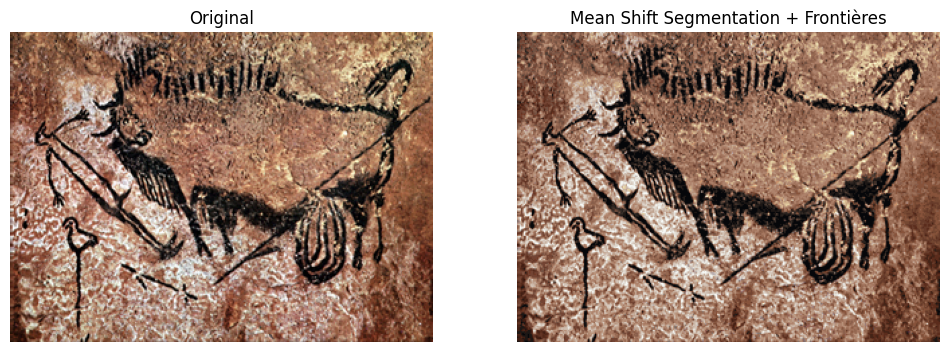

In [435]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_LAB2RGB)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_rgb)
plt.title("Mean Shift Segmentation + Frontières")
plt.axis('off')

plt.show()

In [2]:
from sklearn.cluster import MeanShift
import cv2
import numpy as np

img = cv2.imread("dataset\lascaux\Lascaux_01.jpg")
# img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [ ]:
# img=img[:,:,0]

In [14]:
h, w, _ = img.shape
# h, w = img.shape

# Coordonnées spatiales
xs, ys = np.meshgrid(np.arange(w), np.arange(h))

# Empiler (x, y, r, g, b)
features = np.column_stack((
    xs.flatten(),
    ys.flatten(),
    img.reshape(-1, 3)
)).astype(np.float32)

In [15]:
features

array([[  0.,   0.,   9., 136., 105.],
       [  1.,   0.,  10., 145., 116.],
       [  2.,   0.,  13., 154., 103.],
       ...,
       [312., 230.,   7., 204.,  40.],
       [313., 230.,   6., 192.,  57.],
       [314., 230.,   5., 186.,  96.]], shape=(72765, 5), dtype=float32)

In [16]:
hs = 50   # spatial bandwidth
hr = 70    # color bandwidth

features[:, 0:2] /= hs
features[:, 2:5] /= hr

In [17]:
ms = MeanShift(
    bandwidth=1.0,
    bin_seeding=True
)

print("Clustering Mean Shift...")
labels = ms.fit_predict(features)

Clustering Mean Shift...


In [19]:
labels
np.unique(labels).size

36

In [ ]:
def remove_small_regions(labels, min_size):
    labels_out = labels.copy()
    unique, counts = np.unique(labels, return_counts=True)

    for lab, cnt in zip(unique, counts):
        if cnt < min_size:
            labels_out[labels == lab] = -1

    return labels_out


from scipy.spatial import cKDTree

def merge_small_regions(labels, features, min_size):
    labels = labels.copy()
    unique, counts = np.unique(labels, return_counts=True)

    centers = {}
    for lab in unique:
        centers[lab] = features[labels == lab].mean(axis=0)

    tree = cKDTree(list(centers.values()))
    label_list = list(centers.keys())

    for lab, cnt in zip(unique, counts):
        if cnt < min_size:
            _, idx = tree.query(centers[lab], k=2)
            new_lab = label_list[idx[1]]
            labels[labels == lab] = new_lab

    return labels


In [20]:
labels_img = labels.reshape(h, w)

In [21]:
def region_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)

    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1] or \
               labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 255
    return boundaries


In [24]:
# Image segmentée = moyenne couleur par région
segmented = np.zeros_like(img)

for lab in np.unique(labels):
    mask = labels == lab
    segmented.reshape(-1, 3)[mask] = img.reshape(-1, 3)[mask].mean(axis=0)

boundaries = region_boundaries(labels_img)

# Superposer les frontières en noir
result = segmented.copy()
result[boundaries == 255] = [255,255,255]

cv2.imshow("Mean Shift Segmentation (sklearn)", cv2.cvtColor(result, cv2.COLOR_HSV2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()
